In [1]:
import jax
import jax.numpy as jnp
import matplotlib.colors
import matplotlib.patches
import numpy as np
from matplotlib import pyplot as plt
from xxm.hmm.model import Model

from xxm.core.affine import Affine
from xxm.core.align import match_states_by_conditional_mean
from xxm.core.dists.categorical import Categorical
from xxm.core.dists.gaussian import LinearGaussian
from xxm.core.emissions.discrete_ar import AREmissions, flatten_ar_coefficients
from xxm.core.models.discrete import CategoricalInitial, CategoricalTransitions
from xxm.hmm.inference import infer_exact
from xxm.hmm.init import init_gaussian_ar
from xxm.hmm.learning import fit_em

In [2]:
STATES_CMAP = matplotlib.colors.ListedColormap(['tab:blue', 'tab:orange', 'tab:green'])


def make_true_model() -> Model:
    return Model(
        initial=CategoricalInitial(
            Categorical(probs=jnp.array([0.4, 0.3, 0.3])),
        ),
        transitions=CategoricalTransitions(
            Categorical(
                jnp.array(
                    [
                        [0.97, 0.02, 0.01],
                        [0.02, 0.97, 0.01],
                        [0.02, 0.02, 0.96],
                    ]
                )
            )
        ),
        emissions=AREmissions(
            LinearGaussian(
                Affine(
                    coefficients=flatten_ar_coefficients(
                        jnp.array(
                            [
                                # clockwise rotation
                                [
                                    [
                                        [0.92, 0.32],
                                        [-0.32, 0.92],
                                    ]
                                ],
                                # counter-clockwise rotation
                                [
                                    [
                                        [0.92, -0.32],
                                        [0.32, 0.92],
                                    ]
                                ],
                                # anisotropic dynamics
                                [
                                    [
                                        [0.97, 0.00],
                                        [0.00, 0.65],
                                    ]
                                ],
                            ]
                        )
                    ),  # (K=3, L=1, N=2, N=2)
                    bias=jnp.zeros((3, 2)),
                ),
                covariance=jnp.array(
                    [
                        [[0.05, 0.00], [0.00, 0.05]],
                        [[0.05, 0.00], [0.00, 0.05]],
                        [[0.05, 0.00], [0.00, 0.05]],
                    ]
                ),
            ),
        ),
    )


true_model = make_true_model()

true_states, observations = true_model.sample(
    num_steps=1000,
    key=jax.random.key(0),
)

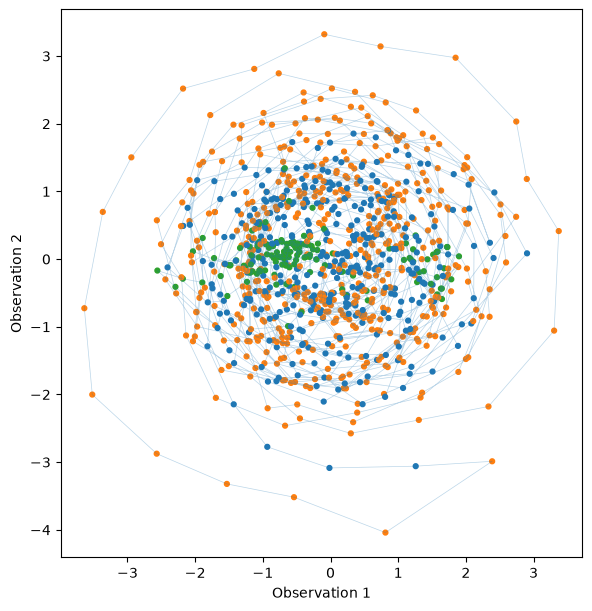

In [3]:
def plot_sequence_2d(
    observations: jnp.ndarray,
    states: jnp.ndarray,
) -> None:
    observations = jnp.asarray(observations)
    states = jnp.asarray(states)

    _f, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)

    ax.plot(
        observations[:, 0],
        observations[:, 1],
        linewidth=0.5,
        alpha=0.3,
    )

    ax.scatter(
        observations[:, 0],
        observations[:, 1],
        c=states,
        s=12,
        cmap=STATES_CMAP,
    )

    ax.set_xlabel('Observation 1')
    ax.set_ylabel('Observation 2')
    ax.set_aspect('equal')


plot_sequence_2d(observations, true_states)

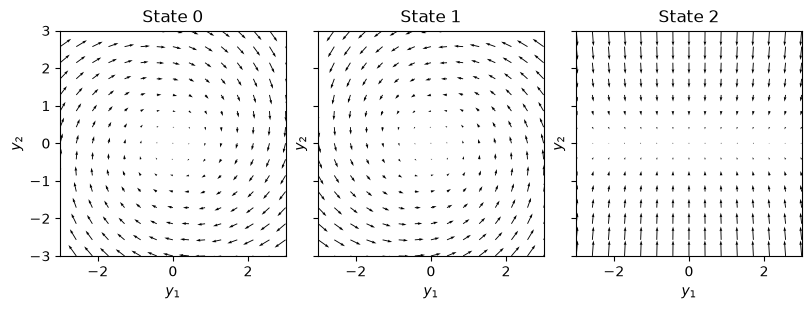

In [4]:
def plot_linear_dynamics(
    ax,
    matrix,
    bias=None,
    xlim=(-3, 3),
    ylim=(-3, 3),
    num_points=15,
    **kwargs,
):
    """Plot the expected displacement field of 2D linear dynamics."""
    matrix = np.asarray(matrix)

    if bias is None:
        bias = np.zeros(2)
    else:
        bias = np.asarray(bias)

    x = np.linspace(*xlim, num_points)  # type: ignore
    y = np.linspace(*ylim, num_points)  # type: ignore
    xx, yy = np.meshgrid(x, y)

    points = np.stack([xx, yy], axis=-1)  # (..., 2)

    next_points = points @ matrix.T + bias
    displacement = next_points - points

    ax.quiver(
        xx,
        yy,
        displacement[..., 0],
        displacement[..., 1],
        **kwargs,
    )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal')
    ax.set_xlabel(r'$y_1$')
    ax.set_ylabel(r'$y_2$')


def plot_model_dynamics(model: Model) -> None:
    """Plot the expected displacement field of a 2D linear dynamics model."""

    _fig, axs = plt.subplots(
        figsize=(8, 6),
        ncols=model.emissions.num_states,
        sharex='all',
        sharey='all',
        constrained_layout=True,
        squeeze=False,
    )

    axs = axs.ravel()

    for state, ax in enumerate(axs):
        plot_linear_dynamics(
            ax,
            matrix=model.emissions.model.affine.coefficients[state],
            bias=model.emissions.model.affine.bias[state],
        )

        ax.set_title(f'State {state}')


plot_model_dynamics(true_model)

In [5]:
posterior, _ = infer_exact(true_model, observations)

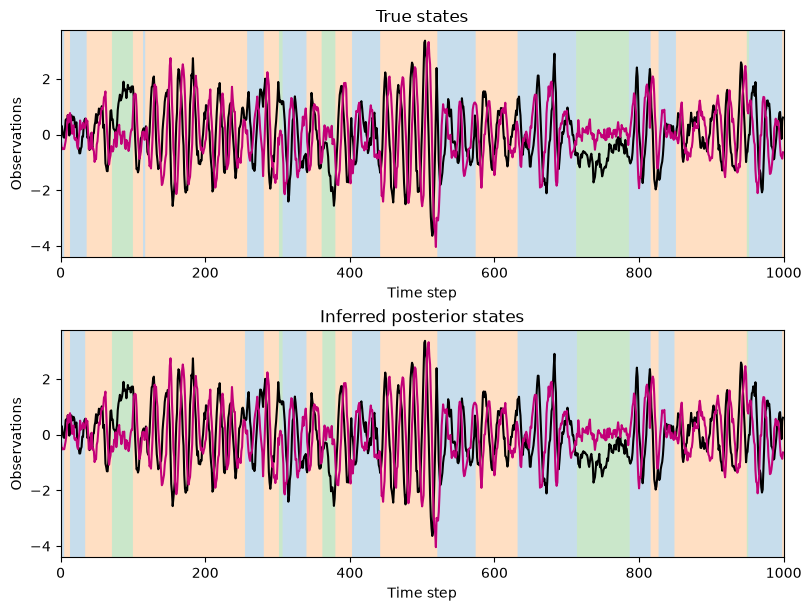

In [6]:
def plot_sequence_1d(
    ax,
    observations: jnp.ndarray,
    states: jnp.ndarray,
) -> None:
    observations = jnp.asarray(observations)
    states = jnp.asarray(states)

    ax.imshow(
        states.reshape(-1, 1).T,
        aspect='auto',
        cmap=STATES_CMAP,
        vmin=0,
        vmax=2,
        alpha=0.25,
        extent=(0, len(states), 0, 1),
        transform=ax.get_xaxis_transform(),
    )

    ax.plot(observations.T[0], color='k')
    ax.plot(observations.T[1], color='xkcd:magenta')

    ax.set(xlabel='Time step', ylabel='Observations')


def plot_inferred_states(observations, true_states, posterior):
    _f, axs = plt.subplots(nrows=2, constrained_layout=True, figsize=(8, 6))

    ax = axs[0]
    plot_sequence_1d(ax, observations, true_states)

    ax.set(
        title='True states',
    )

    ax = axs[1]
    plot_sequence_1d(ax, observations, posterior.state_probs.argmax(axis=1))
    ax.set(
        title='Inferred posterior states',
    )


plot_inferred_states(observations, true_states, posterior)

EM:   0%|          | 0/50 [00:00<?, ?it/s]

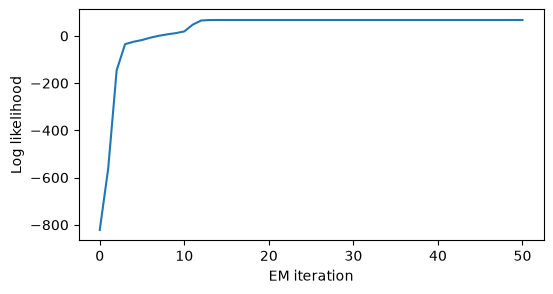

In [7]:
def plot_log_likelihood(log_likelihoods: jnp.ndarray) -> None:
    _f, ax = plt.subplots(figsize=(6, 3))

    ax.plot(np.asarray(log_likelihoods))

    ax.set_xlabel('EM iteration')
    ax.set_ylabel('Log likelihood')


initial_model = init_gaussian_ar(
    key=jax.random.key(0),
    observations=observations,
    num_states=true_model.num_states,
    num_lags=1,
)


fit_em_jit = jax.jit(fit_em, static_argnames=['num_iters', 'progress'])

learned_model, log_likelihoods = fit_em_jit(
    model=initial_model,
    observations=observations,
    num_iters=50,
)


plot_log_likelihood(log_likelihoods)

In [8]:
permutation = match_states_by_conditional_mean(
    true_model.emissions.conditional(observations).mean,
    learned_model.emissions.conditional(observations).mean,
)

matched_model = learned_model.permute(permutation)

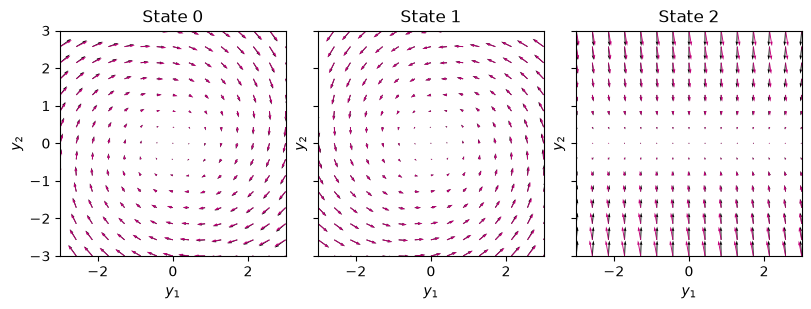

In [9]:
def plot_model_dynamics_comparison(model0: Model, model1: Model) -> None:
    """Plot the expected displacement field of a 2D linear dynamics model."""

    assert model0.num_states == model1.num_states, (
        'Models must have the same number of states.'
    )

    _fig, axs = plt.subplots(
        figsize=(8, 6),
        ncols=model0.num_states,
        sharex='all',
        sharey='all',
        constrained_layout=True,
    )

    for state, ax in enumerate(axs):
        plot_linear_dynamics(
            ax,
            matrix=model0.emissions.model.affine.coefficients[state],
            bias=model0.emissions.model.affine.bias[state],
            color='k',
        )

        plot_linear_dynamics(
            ax,
            matrix=model1.emissions.model.affine.coefficients[state],
            bias=model1.emissions.model.affine.bias[state],
            color='xkcd:magenta',
        )

        ax.set_title(f'State {state}')


plot_model_dynamics_comparison(true_model, matched_model)

In [10]:
posterior, _ = infer_exact(matched_model, observations)

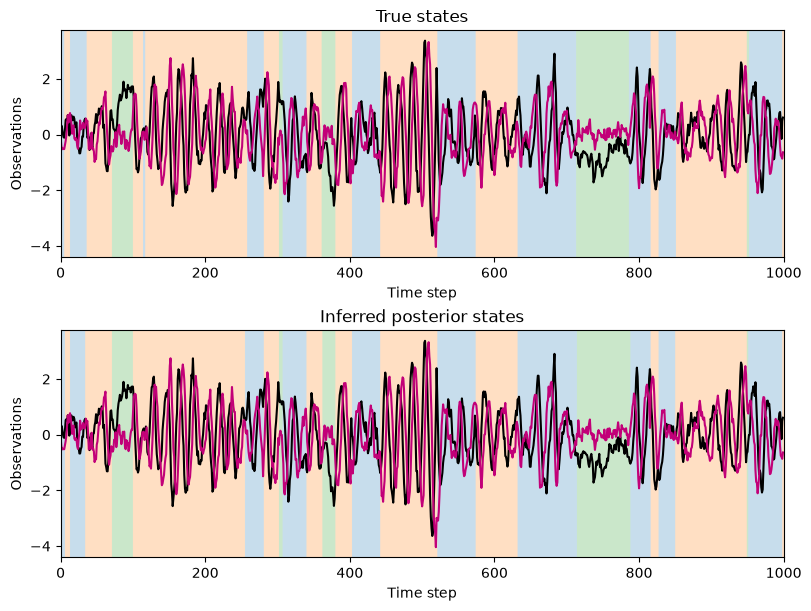

In [11]:
def plot_inferred_states(observations, true_states, posterior):
    _f, axs = plt.subplots(nrows=2, constrained_layout=True, figsize=(8, 6))

    ax = axs[0]
    plot_sequence_1d(ax, observations, true_states)

    ax.set(
        title='True states',
    )

    ax = axs[1]
    plot_sequence_1d(ax, observations, posterior.state_probs.argmax(axis=1))
    ax.set(
        title='Inferred posterior states',
    )


plot_inferred_states(observations, true_states, posterior)